# 1. Importacion de librerias
Se importan las librerias necesarias

In [2]:
import logging
logging.getLogger("torch.utils.flop_counter").setLevel(logging.ERROR)

In [ ]:
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from copy import deepcopy
from pathlib import Path

# ----------------------------

import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
import torch

from keras import layers
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print(f"GPU disponible: {'Si' if torch.cuda.is_available() else 'No'}")


# 2. Definicion de constantes necesarias

In [ ]:
# --------------------------------------------------------
# Carga de dataset
# --------------------------------------------------------

# Tope por clase
N_PER_CLASS = 1000

# Resolucion de entrada
IMG_SIZE = 128

# Imagenes por clase para entrenar en el AG/Random
N_TRAIN_SUB = 100

# Direccion a buscar
DIR_DATASET = Path("data/PlantVillage")

CLASS_NAMES = sorted([dir.name for dir in DIR_DATASET.iterdir() if dir.is_dir()])
N_CLASS = len(CLASS_NAMES)

# Division
SPLIT = (0.70, 0.15, 0.15)


# --------------------------------------------------------
# Algoritmo genetico
# --------------------------------------------------------

# Clase para los hiperparametros
class HyperParams:
    def __init__(
        self,
        alpha: float|None = None,
        batch: int|None = None,
        phi: str|None = None,
        rho: float|None = None
    ):
        self.alpha = alpha
        self.batch = batch
        self.phi = phi
        self.rho = rho

    def __getitem__(
        self, 
        key: str,
    ):
        return getattr(self, key)
    
    def __setitem__(
        self, 
        key: str, 
        value,
    ):
        setattr(self, key, value)

    def keys(
        self,
    ):
        return ["alpha", "batch", "phi", "rho"]

    def copy(
        self,
    ):
        return deepcopy(self)

# Rangos de los hiperparametros
ALPHA = (1e-5, 1e-3)
BATCH = (32, 64)
PHI = ("adam", "sgd", "rmsprop")
RHO = (0.0, 0.50)

def sample_alpha():
    lo, hi = math.log10(ALPHA[0]), math.log10(ALPHA[1])
    return 10 ** random.uniform(lo, hi)

# Tipo de cruzamiento por hiperparámetro:
UNIFORM_CROSS = ("batch", "phi")
BLEND_CROSSOVER = ("alpha", "rho")

# Poblacion
POP_SIZE = 8

# Probabilidad de mutacion:
MUTATION_RATE = 0.20

# Generaciones maximas
GEN_MAX = 10

# Paciencia en las generaciones
GEN_PAT = 4

# Individuos base en la seleccion
K_SELECT = 3

# Epocas para la busqueda (dos etapas)
EPOCHS_HEAD = 2
EPOCHS_FT = 3

# Epocas para el entrenamiento final (dos etapas)
EPOCHS_HEAD_FINAL = 4
EPOCHS_FT_FINAL = 10

# Fine-tuning
FT_UNFREEZE_FRAC = 0.20
FT_LR_FACTOR = 0.10

# Semilla fija del fitness (determinista)
EVAL_SEED = 1234

# Inicializacion con semilla
SEED = 29
random.seed(SEED)
np.random.seed(SEED)

# --------------------------------------------------------
# Modelos de CNN
# --------------------------------------------------------
N_CLASS = 3

OPTIMIZERS = {
    "adam": keras.optimizers.Adam,
    "sgd": keras.optimizers.SGD,
    "rmsprop": keras.optimizers.RMSprop,
}

MODELS = {
    "MobileNetV2": {
        "fn": keras.applications.MobileNetV2,
        "preprocess": keras.applications.mobilenet_v2.preprocess_input,
    },
    "EfficientNetB0": {
        "fn": keras.applications.EfficientNetB0,
        "preprocess": keras.applications.efficientnet.preprocess_input,
    },
}


# 3. Carga de dataset y division
### Se define las constantes necesarias para este apartado


In [5]:
print("="*60)
print("Clases presentes: ")
[print(f"   - {class_name}") for class_name in CLASS_NAMES]
print("="*60)

Clases presentes: 
   - Potato___Early_blight
   - Potato___Late_blight
   - Potato___healthy


### Funcion para la carga del dataset

In [ ]:
def load_images(
    data_dir: Path,
):
    X, y = [], []

    for idx, cname in enumerate(CLASS_NAMES):

        files = sorted((data_dir / cname).glob("*.JPG"))

        if len(files) > N_PER_CLASS:
            files = random.sample(files, N_PER_CLASS)

        for p in files:
            img = Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
            X.append(np.asarray(img, dtype=np.uint8))
            y.append(idx)
    
    return np.stack(X), np.array(y)


Total: (552, 224, 224, 3)


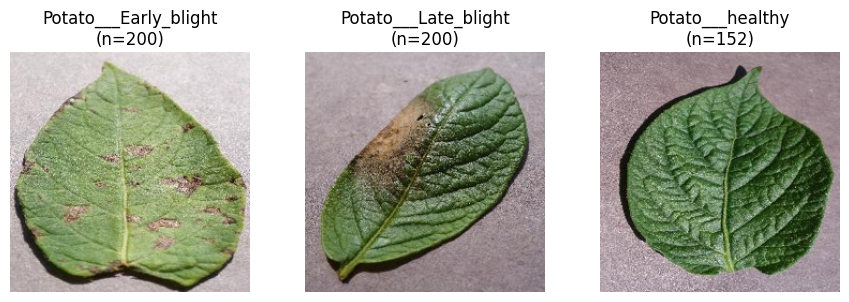

In [7]:
# Visualizacion del total de imagenes
X_raw, y_all = load_images(
    DIR_DATASET,
)

print("="*60)
print(f"Total: {X_raw.shape}")
print("="*60)

plt.figure(figsize=(3 * N_CLASS, 3))
for idx, cname in enumerate(CLASS_NAMES):
    i = np.where(y_all == idx)[0][0]                 
    plt.subplot(1, N_CLASS, idx + 1)
    plt.imshow(X_raw[i])
    plt.title(f"{cname}\n(n={np.sum(y_all == idx)})")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Funcion para la division del dataset

In [8]:
train_frac, valid_frac, test_frac = SPLIT

X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, 
    y_all, 
    test_size=(test_frac + valid_frac), 
    stratify=y_all, 
    random_state=SEED,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, 
    y_temp, 
    test_size=test_frac/(test_frac + valid_frac), 
    stratify=y_temp, 
    random_state=SEED,
)
print("="*60)
print(f"Train: {X_train.shape[0]}")
print(f"Valid: {X_val.shape[0]}")
print(f"Test: {X_test.shape[0]}")
print("="*60)

Train: 386
Valid: 83
Test: 83


### Hallar pesos de clase debido al desbalance

In [9]:
cw = compute_class_weight("balanced", classes=np.arange(N_CLASS), y=y_train)
CLASS_WEIGHT = {i: float(w) for i, w in enumerate(cw)}

print("="*60)
[print(f"   - {class_name}: {CLASS_WEIGHT[idx]}") for idx, class_name in enumerate(CLASS_NAMES)]
print("="*60)

   - Potato___Early_blight: 0.919047619047619
   - Potato___Late_blight: 0.919047619047619
   - Potato___healthy: 1.2138364779874213


In [ ]:
rng_sub = np.random.RandomState(SEED)
sub_idx = []
for c in range(N_CLASS):
    idx_c = np.where(y_train == c)[0]
    if len(idx_c) > N_TRAIN_SUB:
        idx_c = rng_sub.choice(idx_c, N_TRAIN_SUB, replace=False)
    sub_idx.extend(idx_c)
sub_idx = np.array(sub_idx)

X_train_sub, y_train_sub = X_train[sub_idx], y_train[sub_idx]

cw_sub = compute_class_weight("balanced", classes=np.arange(N_CLASS), y=y_train_sub)
CLASS_WEIGHT_SUB = {i: float(w) for i, w in enumerate(cw_sub)}

print("="*60)
print(f"Train completo: {X_train.shape[0]}  |  Subset AG: {X_train_sub.shape[0]}")
print("="*60)

# 4. Funciones y clases necesarias para el Entrenamiento de CNN
### Funcion para generar un modelo

In [ ]:
def build_model(
    backbone: str,
    hiperparams: HyperParams,
):
    base = MODELS[backbone]["fn"](
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )
    base.trainable = False

    data_aug = keras.Sequential(
        [
            layers.RandomFlip("horizontal", seed=123),
        ],
        name="augment"
    )

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_aug(inputs)
    x = layers.Lambda(MODELS[backbone]["preprocess"])(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(hiperparams["rho"])(x)
    outputs = layers.Dense(N_CLASS, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    return model, base

In [ ]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    keras.utils.set_random_seed(seed)


def train_two_stage(model, base, hp, Xtr, ytr, cw, epochs_head, epochs_ft, verbose=0):
    opt = OPTIMIZERS[hp["phi"]]

    base.trainable = False
    model.compile(
        optimizer=opt(learning_rate=hp["alpha"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    model.fit(
        Xtr, ytr,
        validation_data=(X_val, y_val),
        epochs=epochs_head,
        batch_size=hp["batch"],
        class_weight=cw,
        verbose=verbose,
    )

    if epochs_ft > 0 and FT_UNFREEZE_FRAC > 0:
        n_unfreeze = int(len(base.layers) * FT_UNFREEZE_FRAC)
        base.trainable = True
        for layer in base.layers[:-n_unfreeze]:
            layer.trainable = False
        for layer in base.layers[-n_unfreeze:]:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
        model.compile(
            optimizer=opt(learning_rate=hp["alpha"] * FT_LR_FACTOR),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )
        model.fit(
            Xtr, ytr,
            validation_data=(X_val, y_val),
            epochs=epochs_ft,
            batch_size=hp["batch"],
            class_weight=cw,
            verbose=verbose,
        )

    return model

# 5. Funciones y clases necesarias para el AG1

### Definicion de la estrutura del individuo
Se implementa una clase para cada invidiuo, la cual guarde su cromosoma, fitness y tenga metodos para el cruzamiento y mutaciones.

In [ ]:
class Individual:
    def __init__(
        self,
        chromosome: HyperParams|None = None,
    ):
        if chromosome is not None:
            self.chromosome = chromosome.copy()
        else:
            raise ValueError("Error: chromosome es nulo")
        
        self.fitness: float = -1.0

    def set_fitness(
        self,
        value,
    ):
        if isinstance(value, np.ndarray):
            value = value.item()
        self.fitness = float(value)

    def crossover(
        self,
        other,
    ):
        chromosome1 = HyperParams()
        chromosome2 = HyperParams()

        # Se hace un cruzamiento uniforme para los genes phi y batch:
        for param in UNIFORM_CROSS:
            if random.uniform(0, 1) <= 0.5:
                chromosome1[param] = self.chromosome[param]
                chromosome2[param] = other.chromosome[param]
            else:
                chromosome1[param] = other.chromosome[param]
                chromosome2[param] = self.chromosome[param]

        # Se hace un cruzamiento blend para los genes alpha y rho:
        for param in BLEND_CROSSOVER:
            w = random.uniform(0, 1)
            if param == "alpha":
                la = math.log10(self.chromosome[param])
                lb = math.log10(other.chromosome[param])
                chromosome1[param] = 10 ** (w * la + (1 - w) * lb)
                chromosome2[param] = 10 ** (w * lb + (1 - w) * la)
            else:
                a = self.chromosome[param]
                b = other.chromosome[param]
                chromosome1[param] = w * a + (1 - w) * b
                chromosome2[param] = w * b + (1 - w) * a

        return Individual(chromosome1), Individual(chromosome2)
    
    def mutation(
        self,
    ):
        chromosome = self.chromosome.copy()

        for param in chromosome.keys():
            if random.uniform(0, 1) <= MUTATION_RATE:
                if param == "alpha":
                    chromosome[param] = sample_alpha()
                elif param == "batch":
                    chromosome[param] = random.choice(BATCH)
                elif param == "phi":
                    chromosome[param] = random.choice(PHI)
                elif param == "rho":
                    chromosome[param] = random.uniform(*RHO)

        return Individual(chromosome)

### Funcion para obtener el fitness de un cromosoma

In [ ]:
def get_fitness(
    backbone: str,
    chromosome: HyperParams,
):
    py_state = random.getstate()
    np_state = np.random.get_state()

    keras.backend.clear_session()
    set_all_seeds(EVAL_SEED)

    model, base = build_model(
        backbone,
        chromosome
    )

    t0 = time.time()
    train_two_stage(
        model, base, chromosome,
        X_train_sub, y_train_sub, CLASS_WEIGHT_SUB,
        EPOCHS_HEAD, EPOCHS_FT,
    )
    train_time = time.time() - t0

    y_prob = model.predict(
        X_val,
        verbose=0,
    )
    y_pred = np.argmax(y_prob, axis=1)

    f1_macro = f1_score(y_val, y_pred, average="macro")

    del model
    torch.cuda.empty_cache()

    random.setstate(py_state)
    np.random.set_state(np_state)

    print(f"alpha={chromosome['alpha']:.2e} batch={chromosome['batch']:>2} "
          f"phi={chromosome['phi']} rho={chromosome['rho']:.2f} | "
          f"F1={f1_macro:.4f}  t={train_time:5.1f}s")
    return f1_macro

### Funcion para evaluar una poblacion de individuos

In [13]:
def eval_population(
    backbone: str,
    population: list[Individual],
):
    pop_size = len(population)

    for i in range(pop_size):
        if population[i].fitness == -1:
            fitness = get_fitness(
                backbone,
                population[i].chromosome,
            )
            population[i].set_fitness(fitness)

### Funcion para inicializar una poblacion de individuos


In [ ]:
def init_population(
    size: int, 
):
    population = []
    
    for _ in range(size):
        alpha = sample_alpha()
        batch = random.choice(BATCH)
        phi = random.choice(PHI)
        rho = random.uniform(*RHO)

        chromosome = (alpha, batch, phi, rho)
        population.append(Individual(HyperParams(*chromosome)))
    
    return population


### Funcion para la seleccion de padres

In [15]:
def select_parents(
    population: list[Individual],
    tournament_size: int,
):
    list_indiv = []

    x1 = np.random.permutation(len(population))
    y1 = x1[:tournament_size]

    for i in range(tournament_size):
        list_indiv.append(population[y1[i]].fitness)

    iParent1 = np.argmax(list_indiv)

    list_indiv = []
    x2 = np.delete(x1, iParent1)
    x2 = np.random.permutation(x2)
    y2 = x2[:tournament_size]

    for i in range(tournament_size):
        list_indiv.append(population[y2[i]].fitness)

    iParent2 = np.argmax(list_indiv)

    return population[y1[iParent1]], population[y2[iParent2]]

### Funcion para la seleccion de la poblacion

In [16]:
def select_survivors(
    population: list[Individual],
    offspring: list[Individual],
    num_survivors: int,
):
    next_population = []
    population.extend(offspring)
    population.sort(key=lambda x: x.fitness, reverse=True)

    next_population = population[:num_survivors]
    
    return next_population

    

### Algoritmo genetico para encontrar soluciones

In [ ]:
def genetic_algo(
    backbone,
    population,
    n_gen = GEN_MAX,
    p_gen = GEN_PAT,
):

    pop_size = len(population)

    eval_population(
        backbone=backbone,
        population=population,
    )

    best = sorted(population, key=lambda x: x.fitness, reverse=True)[0]
    best_fitness = [best.fitness]

    f0 = [i.fitness for i in population]
    ag_stats = [
        {
            "gen": 0, "best": float(best.fitness),
            "mean": float(np.mean(f0)), "std": float(np.std(f0))
        }
    ]

    print(f"Poblacion inicial, mejor fitness = {best_fitness[:1]}")

    no_improve = 0
    TOL = 1e-4

    for gen in range(n_gen):

        mating_pool = []

        for i in range(int(pop_size/2)):
            mating_pool.append(select_parents(
                population=population,
                tournament_size=K_SELECT,
            ))

        offspring = []

        for i in range(int(pop_size/2)):
            papa = mating_pool[i][0]
            mama = mating_pool[i][1]
            offspring.extend(papa.crossover(
                other=mama
            ))

        offspring = [child.mutation() for child in offspring]

        eval_population(
            backbone=backbone,
            population=offspring,
        )

        population = select_survivors(
            population=population,
            offspring=offspring,
            num_survivors=pop_size,
        )

        best = sorted(population, key=lambda x: x.fitness, reverse=True)[0]
        best_fitness.append(best.fitness)

        f = [i.fitness for i in population]
        ag_stats.append(
            {
                "gen": gen + 1, "best": float(best.fitness),
                "mean": float(np.mean(f)), "std": float(np.std(f))
            }
        )

        if best_fitness[-1] > best_fitness[-2] + TOL:
            no_improve = 0
            print(f"Generacion {gen + 1}, mejor fitness = {best_fitness[-1]}")
        else:
            no_improve += 1
            print(f"Generacion {gen + 1}, mejor fitness = {best_fitness[-1]:.4f}. (sin mejora {no_improve}/{p_gen})")

            if no_improve >= p_gen:
                print(f"Early stopping: {p_gen} generaciones sin mejora.")
                break

    print(f"Mejor individuo final, fitness = {best_fitness[-1]}")
    return best, best_fitness, ag_stats

# 6. Funciones necesarias para RandomSearch
### Funcion RandomSearch

In [18]:
def random_search(
    backbone: str,
    n_evals: int,
):
    population = init_population(n_evals)
    eval_population(
        backbone=backbone,
        population=population,
    )

    best = None
    best_so_far = []
    for indiv in population:
        if best is None or indiv.fitness > best.fitness:
            best = indiv
        best_so_far.append(best.fitness)


    print(f"\nRandom Search | mejor fitness = {best.fitness:.4f}")
    return best, best_so_far

# 7. Helpers para el testeo final
### Evaluar testeo

In [ ]:
def evaluate_test(
    backbone: str,
    chromosome: HyperParams,
):
    py_state = random.getstate()
    np_state = np.random.get_state()

    keras.backend.clear_session()
    set_all_seeds(EVAL_SEED)

    model, base = build_model(backbone, chromosome)
    train_two_stage(
        model, base, chromosome,
        X_train, y_train, CLASS_WEIGHT,
        EPOCHS_HEAD_FINAL, EPOCHS_FT_FINAL,
    )

    y_prob = model.predict(
        X_test,
        verbose=0,
    )
    y_pred = np.argmax(y_prob, axis=1)

    f1  = f1_score(y_test, y_pred, average="macro")
    acc = accuracy_score(y_test, y_pred)

    del model
    torch.cuda.empty_cache()

    random.setstate(py_state)
    np.random.set_state(np_state)

    return f1, acc, y_pred

# Ex1 Funciones y clases necesarias para el Entrenamiento de CNN

In [ ]:
BACKBONE = "EfficientNetB0"

### Se realiza la prueba con la configuracion por defecto

In [ ]:
print("="*60)
print("ESTRATEGIA 3: Configuración por defecto")
print("="*60)
default_chr = HyperParams(0.001, 32, "adam", 0.2)
default_indiv = Individual(default_chr)
default_indiv.set_fitness(get_fitness(BACKBONE, default_chr))

ESTRATEGIA 3: Configuración por defecto


### Se realiza la prueba mediante el AG propuesto

In [ ]:
print("="*60)
print("Algoritmo Genético")
print("="*60)
np.random.seed(SEED); random.seed(SEED)

population = init_population(POP_SIZE)
ag_best, ag_curve, ag_stats = genetic_algo(BACKBONE, population)

### Se realiza la prueba mediante RandomSearch

In [ ]:
n_evals = POP_SIZE * len(ag_curve)
print("="*60)
print(f"Random Search ({n_evals} evaluaciones)")
print("="*60)
rs_best, rs_curve = random_search(BACKBONE, n_evals)

### Resumen

In [ ]:
print(f"Resumen (fitness en VALIDACIÓN):")
print(f"    - AG     : {ag_best.fitness:.4f}")
print(f"    - Random : {rs_best.fitness:.4f}")
print(f"    - Default: {default_indiv.fitness:.4f}")

### Covergencia

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(np.arange(1, len(ag_curve)+1) * POP_SIZE, ag_curve, marker="o", label="Algoritmo Genético")

plt.plot(np.arange(1, len(rs_curve)+1), rs_curve, marker="s", alpha=0.7, label="Random Search")

plt.axhline(default_indiv.fitness, ls="--", color="gray", label="Default")

plt.xlabel("Número de evaluaciones (entrenamientos)")
plt.ylabel("Mejor fitness (F1-macro val)")
plt.title("Experimento 1: convergencia por estrategia (mismo presupuesto)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Comparativa final de los mejores modelos en base a un entrenamiento completo y testeo

In [ ]:
strategies = {
    "Algoritmo Genético": ag_best.chromosome,
    "Random Search":      rs_best.chromosome,
    "Default":            default_chr,
}

rows, preds = [], {}
for name, chrom in strategies.items():
    f1, acc, y_pred = evaluate_test(BACKBONE, chrom)
    preds[name] = y_pred
    rows.append({
        "Estrategia": name,
        "alpha": chrom["alpha"], "batch": chrom["batch"],
        "phi": chrom["phi"], "rho": round(chrom["rho"], 3),
        "F1_macro_test": round(f1, 4), "Accuracy_test": round(acc, 4),
    })

results_df = pd.DataFrame(rows).sort_values("F1_macro_test", ascending=False)
print(results_df.to_string(index=False))

### Matriz de confusion de la mejor estrategia

In [ ]:
best_name = results_df.iloc[0]["Estrategia"]
cm = confusion_matrix(y_test, preds[best_name])
ConfusionMatrixDisplay(cm, display_labels=[c.replace("Potato___", "") for c in CLASS_NAMES]).plot(cmap="Blues")
plt.title(f"Matriz de confusión en Test — {best_name}")
plt.tight_layout(); plt.show()

# End. Guardado final para siguientes experimentos

In [ ]:
import json, os

def _chr(c):
    return {"alpha": float(c["alpha"]), "batch": int(c["batch"]),
            "phi": str(c["phi"]), "rho": float(c["rho"])}

os.makedirs("results", exist_ok=True)

result = {
    "backbone": BACKBONE,
    "seed": SEED,
    "config": {
        "N_PER_CLASS": N_PER_CLASS, "SPLIT": list(SPLIT),
        "POP_SIZE": POP_SIZE, "GEN_MAX": GEN_MAX, "GEN_PAT": GEN_PAT,
        "K_SELECT": K_SELECT, "MUTATION_RATE": MUTATION_RATE,
        "EPOCHS_HEAD": EPOCHS_HEAD, "EPOCHS_FT": EPOCHS_FT,
        "EPOCHS_HEAD_FINAL": EPOCHS_HEAD_FINAL, "EPOCHS_FT_FINAL": EPOCHS_FT_FINAL,
        "FT_UNFREEZE_FRAC": FT_UNFREEZE_FRAC, "FT_LR_FACTOR": FT_LR_FACTOR,
        "space": {"ALPHA": list(ALPHA), "BATCH": list(BATCH), "PHI": list(PHI), "RHO": list(RHO)},
    },
    
    "ag_curve": [float(x) for x in ag_curve],
    "ag_stats": globals().get("ag_stats"),
    "rs_curve": [float(x) for x in rs_curve],

    "winners": {
        "AG":      {"chromosome": _chr(ag_best.chromosome), "val_fitness": float(ag_best.fitness)},
        "RS":      {"chromosome": _chr(rs_best.chromosome), "val_fitness": float(rs_best.fitness)},
        "Default": {"chromosome": _chr(default_chr),        "val_fitness": float(default_indiv.fitness)},
    },

    "test": results_df.to_dict(orient="records"),
    
    "class_names": CLASS_NAMES,
    "y_test": [int(v) for v in y_test],
    "preds": {k: [int(v) for v in p] for k, p in preds.items()},
}

fname = f"results/{BACKBONE}_seed{SEED}.json"
with open(fname, "w") as f:
    json.dump(result, f, indent=2)
print(f"Guardado: {fname}")